# Getting Started with OlmoEarth: From Embeddings to Fine-tuning

**A Tutorial for Land Use/Land Cover Classification in Kenya**

This tutorial demonstrates how to use [OlmoEarth](https://huggingface.co/collections/allenai/olmoearth), a state-of-the-art foundation model for Earth observation, for land use and land cover (LULC) classification. We'll work with data from the African Wildlife Foundation (AWF) covering southern Kenya near Amboseli National Park.

## What You'll Learn

1. **Extract embeddings** from satellite imagery using OlmoEarth for rapid prototyping
2. **Train simple classifiers** (kNN, linear probe) on top of embeddings
3. **Fine-tune OlmoEarth** for maximum accuracy

## Why Two Approaches?

| Approach | Accuracy | Time | GPU Memory | Best For |
|----------|----------|------|------------|----------|
| Embeddings + kNN/LP | ~70-75% | Minutes | ~2-3 GB | Rapid prototyping, limited compute |
| Fine-tuning (4 epochs) | ~70-75% | ~15-20 min | ~4-6 GB | Quick fine-tuning |
| Fine-tuning (30 epochs) | ~82-87% | ~2-3 hours | ~4-6 GB | Maximum accuracy |

## Requirements

- Google Colab with GPU runtime (T4 is sufficient)
- ~30-45 minutes with default settings (can increase epochs for better accuracy)

**Let's get started!**

---
## 1. Setup & Installation

First, let's verify we have GPU access and install the required packages.

In [1]:
# Check GPU availability
!nvidia-smi

Mon May 18 09:25:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
# Core imports
import os
import json

# Enable MPS fallback for unsupported operations (needed for OlmoEarth on Apple Silicon)
# IMPORTANT: Must be set before importing torch
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from collections import Counter

# ML imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sklearn.preprocessing as preprocessing

# Remote sensing imports
import rasterio
from einops import rearrange
from scipy.ndimage import zoom

# rslearn imports
from rslearn.dataset import Dataset
from upath import UPath

# OlmoEarth imports
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config

# Device detection helper function
def get_device():
    """Get the best available device (CUDA > MPS > CPU)."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def print_device_info(device):
    """Print device information."""
    if device.type == "cuda":
        print(f"Using device: {device}")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
        print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif device.type == "mps":
        print(f"Using device: {device} (Apple Silicon GPU)")
        print("  Note: Some operations may fall back to CPU")
    else:
        print(f"Using device: {device}")
        print("  Warning: No GPU available, training will be slow")

device = get_device()
print_device_info(device)

/shared/home/rdercole/Riccardo/projects/GeoAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/shared/home/rdercole/Riccardo/projects/GeoAI/.venv/lib/python3.12/site-packages/olmoearth_pretrain/model_loader.py:37: UserWarning: olmo-core not installed. Running in inference-only mode. For training: pip install olmoearth-pretrain[training]
  from olmoearth_pretrain.config import Config


Using device: cuda
  GPU: NVIDIA RTX A6000
  Memory: 47.7 GB


---
## 2. Download the Dataset

We'll download the pre-prepared AWF dataset from HuggingFace. The dataset consists of:
- **1,460 labeled latitude/longitude points** in Kenya, each with a land cover class label
- **63×63 pixel Sentinel-2 windows** (at 10m resolution, ~630m × 630m) centered on each point
- **12 monthly timesteps** of imagery per window (all 12 Sentinel-2 bands)
- **Spatial train/val split** by longitude to prevent data leakage

**Alternative:** See Section 2b below to learn how to build this dataset from scratch using `rslearn` and GeoJSON labels.

In [4]:
# Create data directory and download dataset
!mkdir -p data

# Download from HuggingFace (about 1.8GB)
!wget -q --show-progress https://huggingface.co/datasets/allenai/olmoearth_projects_awf/resolve/main/dataset.tar -O data/awf_dataset.tar

# Extract
!tar -xf data/awf_dataset.tar -C data/
!ls -la data/

data/awf_dataset.ta 100%[===================>]   1.74G   140MB/s    in 9.9s    
total 1825428
drwxr-xr-x 3 root root       4096 May 18 09:20 .
drwxr-xr-x 1 root root       4096 May 18 09:20 ..
-rw-r--r-- 1 root root 1869219840 May 18 09:20 awf_dataset.tar
drwxr-xr-x 4 root root       4096 Oct 26  2025 dataset


---
## 2b. (Optional) Building the Dataset from Scratch

**Skip this section if you downloaded the pre-built dataset above.**

This section demonstrates how to build the AWF dataset from scratch using `rslearn`. This is useful for:
- Understanding the full data pipeline
- Creating your own datasets from GeoJSON labels
- Working with different geographic regions or time periods

The process involves:
1. Download GeoJSON point labels from HuggingFace
2. Create an rslearn dataset configuration
3. Add windows centered on each labeled point
4. Query Planetary Computer for matching Sentinel-2 scenes
5. Download and materialize the satellite imagery

**Note:** Building from scratch takes 1-2 hours due to satellite imagery download.

In [5]:
# Install additional dependencies for data ingestion
# !pip install -q planetary-computer pystac-client pyproj

# Skip this cell if you're using the pre-built dataset
BUILD_FROM_SCRATCH = False  # Set to True to build dataset from GeoJSON

if BUILD_FROM_SCRATCH:
    import subprocess
    from huggingface_hub import hf_hub_download

    # Create output directory
    GEOJSON_DIR = Path("data/geojson")
    DATASET_FROM_SCRATCH = Path("data/dataset_from_scratch")
    GEOJSON_DIR.mkdir(parents=True, exist_ok=True)
    DATASET_FROM_SCRATCH.mkdir(parents=True, exist_ok=True)

    # Step 1: Download GeoJSON labels from HuggingFace
    print("Step 1: Downloading GeoJSON labels from HuggingFace...")
    hf_hub_download(
        repo_id="allenai/olmoearth_projects_awf",
        filename="annotation_features.geojson",
        repo_type="dataset",
        local_dir=str(GEOJSON_DIR)
    )
    print("  Downloaded: annotation_features.geojson")

    # Load and inspect the GeoJSON
    with open(GEOJSON_DIR / "annotation_features.geojson") as f:
        geojson_data = json.load(f)

    features = geojson_data.get("features", [])
    print(f"  Found {len(features)} labeled points")

    # Show a sample feature
    sample = features[0]
    coords = sample["geometry"]["coordinates"]
    category = sample["properties"].get("oe_labels", {}).get("category")
    print(f"  Sample: coords={coords}, category={category}")
else:
    print("Skipping dataset build from scratch (using pre-built dataset)")

Skipping dataset build from scratch (using pre-built dataset)


In [6]:
if BUILD_FROM_SCRATCH:
    # Step 2: Split into train/val (spatial split by longitude)
    print("\nStep 2: Creating spatial train/val split...")

    # Sort by longitude for spatial split
    features_sorted = sorted(features, key=lambda f: f["geometry"]["coordinates"][0])

    # Take every 5th as validation
    train_features = [f for i, f in enumerate(features_sorted) if i % 5 != 0]
    val_features = [f for i, f in enumerate(features_sorted) if i % 5 == 0]

    print(f"  Train: {len(train_features)} points")
    print(f"  Val: {len(val_features)} points")

    # Save split files
    with open(GEOJSON_DIR / "train.geojson", "w") as f:
        json.dump({"type": "FeatureCollection", "features": train_features}, f)
    with open(GEOJSON_DIR / "val.geojson", "w") as f:
        json.dump({"type": "FeatureCollection", "features": val_features}, f)

    # Step 3: Create rslearn dataset configuration
    print("\nStep 3: Creating rslearn dataset configuration...")

    # The config defines layers and data sources
    # Sentinel-2 uses 3 band_sets at different native resolutions
    dataset_config = {
        "layers": {
            "label": {
                "type": "raster",
                "band_sets": [{"bands": ["category"], "dtype": "int32"}]
            },
            "sentinel2": {
                "type": "raster",
                "band_sets": [
                    {"bands": ["B02", "B03", "B04", "B08"], "dtype": "uint16"},  # 10m
                    {"bands": ["B05", "B06", "B07", "B8A", "B11", "B12"], "dtype": "uint16", "zoom_offset": -1},  # 20m
                    {"bands": ["B01", "B09"], "dtype": "uint16", "zoom_offset": -2}  # 60m
                ],
                "data_source": {
                    "class_path": "rslearn.data_sources.planetary_computer.Sentinel2",
                    "ingest": False,
                    "init_args": {
                        "cache_dir": "cache/planetary_computer",
                        "harmonize": True,
                        "sort_by": "eo:cloud_cover"
                    },
                    "query_config": {
                        "space_mode": "PER_PERIOD_MOSAIC",
                        "max_matches": 12,
                        "min_matches": 12,
                        "period_duration": "30d"
                    }
                }
            }
        }
    }

    config_path = DATASET_FROM_SCRATCH / "config.json"
    with open(config_path, "w") as f:
        json.dump(dataset_config, f, indent=2)
    print(f"  Created: {config_path}")

In [7]:
if BUILD_FROM_SCRATCH:
    # Step 4: Add windows from GeoJSON points
    print("\nStep 4: Adding windows from GeoJSON labels...")
    print("  Each window is 63x63 pixels at 10m resolution, centered on a labeled point")

    # Time range for 2023 (matching AWF training data)
    START_TIME = "2023-01-01T00:00:00+00:00"
    END_TIME = "2023-12-31T23:59:59+00:00"

    for split, geojson_file in [("train", "train.geojson"), ("val", "val.geojson")]:
        cmd = [
            "rslearn", "dataset", "add_windows",
            "--root", str(DATASET_FROM_SCRATCH),
            "--group", split,
            "--fname", str(GEOJSON_DIR / geojson_file),
            "--window_size", "63",
            "--resolution", "10",
            "--utm",
            "--start", START_TIME,
            "--end", END_TIME
        ]
        print(f"  Adding {split} windows...")
        result = subprocess.run(cmd, capture_output=True, text=True)
        if result.returncode != 0:
            print(f"  Error: {result.stderr}")

    # Step 5: Prepare (match Sentinel-2 scenes to windows)
    print("\nStep 5: Preparing dataset (querying Planetary Computer)...")
    print("  This queries for Sentinel-2 scenes covering each window location and time range")

    result = subprocess.run(
        ["rslearn", "dataset", "prepare", "--root", str(DATASET_FROM_SCRATCH), "--workers", "4"],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print("  Prepare completed!")
    else:
        print(f"  Warning: {result.stderr[:200]}...")

In [8]:
if BUILD_FROM_SCRATCH:
    # Step 6: Materialize (download Sentinel-2 imagery)
    # WARNING: This takes 1-2 hours for the full dataset!
    MATERIALIZE = False  # Set to True to actually download imagery

    if MATERIALIZE:
        print("\nStep 6: Materializing dataset (downloading Sentinel-2 imagery)...")
        print("  This downloads and crops satellite imagery for each window")
        print("  Expected time: 1-2 hours for full dataset")

        result = subprocess.run(
            ["rslearn", "dataset", "materialize", "--root", str(DATASET_FROM_SCRATCH),
             "--workers", "4", "--no-use-initial-job"]
        )
        if result.returncode == 0:
            print("  Materialize completed!")
            # Update DATASET_PATH to use the newly built dataset
            DATASET_PATH = UPath(str(DATASET_FROM_SCRATCH))
            print(f"\n  Using built dataset: {DATASET_PATH}")
    else:
        print("\nStep 6: Skipping materialization (MATERIALIZE=False)")
        print("  Set MATERIALIZE=True and re-run to download imagery")
        print("  For this tutorial, we'll use the pre-built dataset instead")

    print("\n" + "="*60)
    print("Data Ingestion Pipeline Summary:")
    print("  1. Download GeoJSON labels from HuggingFace")
    print("  2. Create spatial train/val split")
    print("  3. Create rslearn dataset configuration")
    print("  4. Add windows (63x63 @ 10m) from point labels")
    print("  5. Prepare: Query Planetary Computer for Sentinel-2 scenes")
    print("  6. Materialize: Download and crop imagery to windows")
    print("="*60)

---
## 3. Understanding the Dataset

The AWF dataset contains point labels for land use/land cover classification in southern Kenya. Labels were created by the African Wildlife Foundation using high-resolution Planet imagery as reference.

### Land Cover Classes (9 total)

| ID | Class Name | Description |
|----|------------|-------------|
| 0 | Woodland Forest | >40% canopy cover |
| 1 | Open Water | Lakes, rivers |
| 2 | Shrubland/Savanna | Typical savanna vegetation |
| 3 | Herbaceous Wetland | Seasonal wetlands |
| 4 | Grassland/Barren | Open grasslands |
| 5 | Agriculture/Settlement | Farmland and rural settlements |
| 6 | Montane Forest | Highland forests |
| 7 | Lava Forest | Forests on volcanic soils |
| 8 | Urban/Dense Development | Towns and infrastructure |

In [ ]:
# Define class names and constants
CLASS_NAMES = [
    "Woodland Forest",
    "Open Water",
    "Shrubland/Savanna",
    "Herbaceous Wetland",
    "Grassland/Barren",
    "Agriculture/Settlement",
    "Montane Forest",
    "Lava Forest",
    "Urban/Dense Dev."
]

# Colors for visualization (matching each class)
CLASS_COLORS = [
    '#228B22',  # Woodland - forest green
    '#1E90FF',  # Water - dodger blue
    '#DAA520',  # Shrubland - goldenrod
    '#00CED1',  # Wetland - dark turquoise
    '#F4A460',  # Grassland - sandy brown
    '#FF6347',  # Agriculture - tomato
    '#006400',  # Montane - dark green
    '#2F4F4F',  # Lava - dark slate gray
    '#DC143C',  # Urban - crimson
]

NUM_CLASSES = len(CLASS_NAMES)
NODATA_VALUE = 9

# Bandset configuration for Sentinel-2
BANDSET_INFO = [
    ("B02_B03_B04_B08", 4),         # 4 bands at 10m
    ("B05_B06_B07_B8A_B11_B12", 6), # 6 bands at 20m
    ("B01_B09", 2)                   # 2 bands at 60m
]

print(f"Number of classes: {NUM_CLASSES}")
print(f"Nodata value: {NODATA_VALUE}")

Number of classes: 9
Nodata value: 9


In [ ]:
# Load dataset using rslearn
DATASET_PATH = UPath("data/dataset")

print(f"Loading dataset from: {DATASET_PATH}")
dataset = Dataset(DATASET_PATH)

# Load all windows (samples)
print("Loading windows...")
all_windows = list(dataset.load_windows(workers=0))
print(f"Total samples: {len(all_windows)}")

# Split into train and validation
train_windows = [w for w in all_windows if w.options.get("split") == "train"]
val_windows = [w for w in all_windows if w.options.get("split") == "val"]

print(f"Training samples: {len(train_windows)}")
print(f"Validation samples: {len(val_windows)}")
print(f"Train/Val ratio: {len(train_windows)/len(all_windows):.1%} / {len(val_windows)/len(all_windows):.1%}")

Loading dataset from: data/dataset
Loading windows...
Total samples: 1459
Training samples: 1115
Validation samples: 344
Train/Val ratio: 76.4% / 23.6%


/Users/joer/.conda/lib/python3.12/site-packages/rslearn/config/dataset.py:407: FutureWarning: `Data source configuration {'name': ...}` is deprecated; use `{'class_path': '...', 'init_args': {...}, ...}` instead. Support will be removed after 2026-03-01.
  warnings.warn(


In [ ]:
# Helper function to get label from window
def get_label_from_window(window, dataset_path):
    """Extract the valid label from a window."""
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    label_path = window_root / "layers" / "label" / "category" / "geotiff.tif"

    if not label_path.exists():
        return None

    with rasterio.open(str(label_path)) as src:
        label = src.read(1)
        # Find valid label (not nodata and within class range)
        unique = np.unique(label)
        valid_labels = unique[(unique != NODATA_VALUE) & (unique < NUM_CLASSES)]
        if len(valid_labels) > 0:
            return int(valid_labels[0])
    return None

# Analyze class distribution
print("Analyzing class distribution...")
train_labels_list = [get_label_from_window(w, DATASET_PATH) for w in train_windows]
train_labels_list = [l for l in train_labels_list if l is not None and l < NUM_CLASSES]

counter = Counter(train_labels_list)
print(f"\nTraining set class distribution:")
for cls_id in sorted(counter.keys()):
    count = counter[cls_id]
    pct = 100 * count / len(train_labels_list)
    print(f"  {cls_id}: {CLASS_NAMES[cls_id]:25s} - {count:4d} ({pct:5.1f}%)")

Analyzing class distribution...

Training set class distribution:
  0: Woodland Forest           -  123 ( 11.0%)
  1: Open Water                -   44 (  3.9%)
  2: Shrubland/Savanna         -  296 ( 26.5%)
  3: Herbaceous Wetland        -   43 (  3.9%)
  4: Grassland/Barren          -  248 ( 22.2%)
  5: Agriculture/Settlement    -  232 ( 20.8%)
  6: Montane Forest            -   49 (  4.4%)
  7: Lava Forest               -   17 (  1.5%)
  8: Urban/Dense Dev.          -   63 (  5.7%)


### Visualize Sample Images

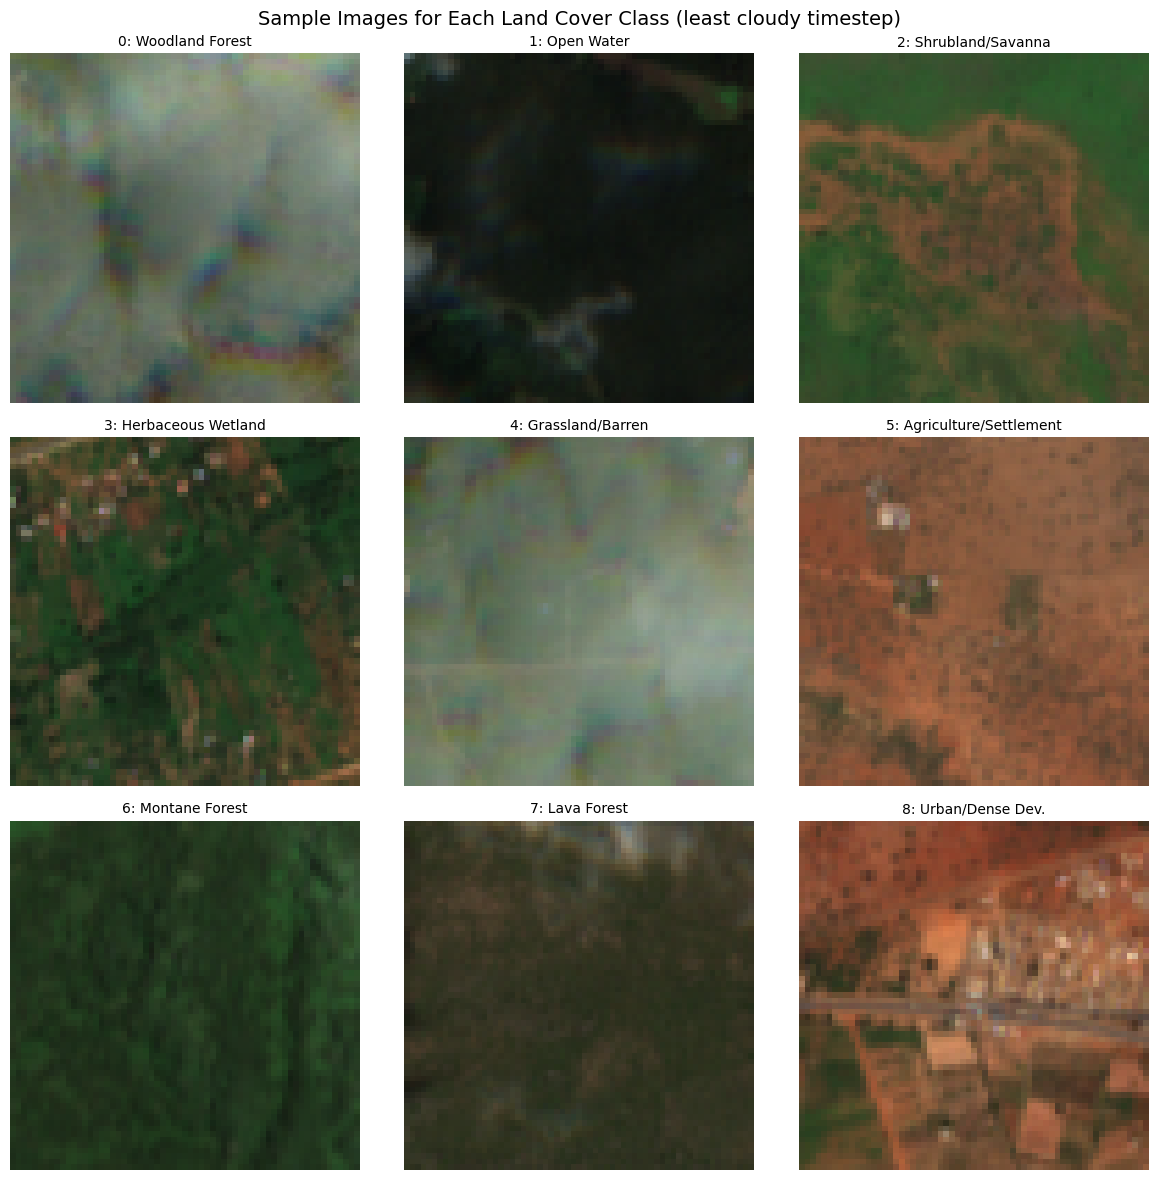

In [ ]:
def load_rgb_image(window, dataset_path, timestep=0):
    """Load RGB composite (B04, B03, B02) from a window."""
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    layer_name = "sentinel2" if timestep == 0 else f"sentinel2.{timestep}"
    rgb_path = window_root / "layers" / layer_name / "B02_B03_B04_B08" / "geotiff.tif"

    if not rgb_path.exists():
        return None

    with rasterio.open(str(rgb_path)) as src:
        # Bands are B02, B03, B04, B08 - we want B04, B03, B02 for RGB
        data = src.read()  # (4, H, W)
        rgb = data[[2, 1, 0], :, :]  # B04, B03, B02

    # Normalize for display: divide by 3000 for consistent cross-image comparison
    # (standard S2 reflectance scaling; avoids per-image percentile normalization)
    rgb = np.clip(rgb.astype(np.float32) / 3000, 0, 1)

    return rgb.transpose(1, 2, 0)  # (H, W, 3)

def find_least_cloudy_timestep(window, dataset_path, num_timesteps=12):
    """Find the least cloudy timestep for a window (based on high reflectance pixels)."""
    best_timestep = num_timesteps - 1  # Default to last (often dry season, less cloudy)
    min_cloud_score = float('inf')

    for t in range(num_timesteps):
        window_root = window.get_window_root(dataset_path, window.group, window.name)
        layer_name = "sentinel2" if t == 0 else f"sentinel2.{t}"
        rgb_path = window_root / "layers" / layer_name / "B02_B03_B04_B08" / "geotiff.tif"

        if not rgb_path.exists():
            continue

        with rasterio.open(str(rgb_path)) as src:
            data = src.read()
            # Cloud metric: count of pixels where min band value > 2000 (bright = likely cloud)
            cloud_score = np.count_nonzero(data.min(axis=0) > 2000)
            if cloud_score < min_cloud_score:
                min_cloud_score = cloud_score
                best_timestep = t

    return best_timestep

# Group windows by class
class_windows = {i: [] for i in range(NUM_CLASSES)}
for w in train_windows:
    label = get_label_from_window(w, DATASET_PATH)
    if label is not None and label < NUM_CLASSES:
        class_windows[label].append(w)

# Display one sample per class (using least cloudy timestep for each)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for cls_id in range(NUM_CLASSES):
    ax = axes[cls_id]
    if class_windows[cls_id]:
        window = class_windows[cls_id][0]
        # Find least cloudy timestep for clearer visualization
        best_t = find_least_cloudy_timestep(window, DATASET_PATH)
        rgb = load_rgb_image(window, DATASET_PATH, timestep=best_t)
        if rgb is not None:
            ax.imshow(rgb)
            ax.set_title(f"{cls_id}: {CLASS_NAMES[cls_id]}", fontsize=10)
        else:
            ax.text(0.5, 0.5, "No image", ha='center', va='center')
    else:
        ax.text(0.5, 0.5, "No samples", ha='center', va='center')
    ax.axis('off')

plt.suptitle("Sample Images for Each Land Cover Class (least cloudy timestep)", fontsize=14)
plt.tight_layout()
plt.show()

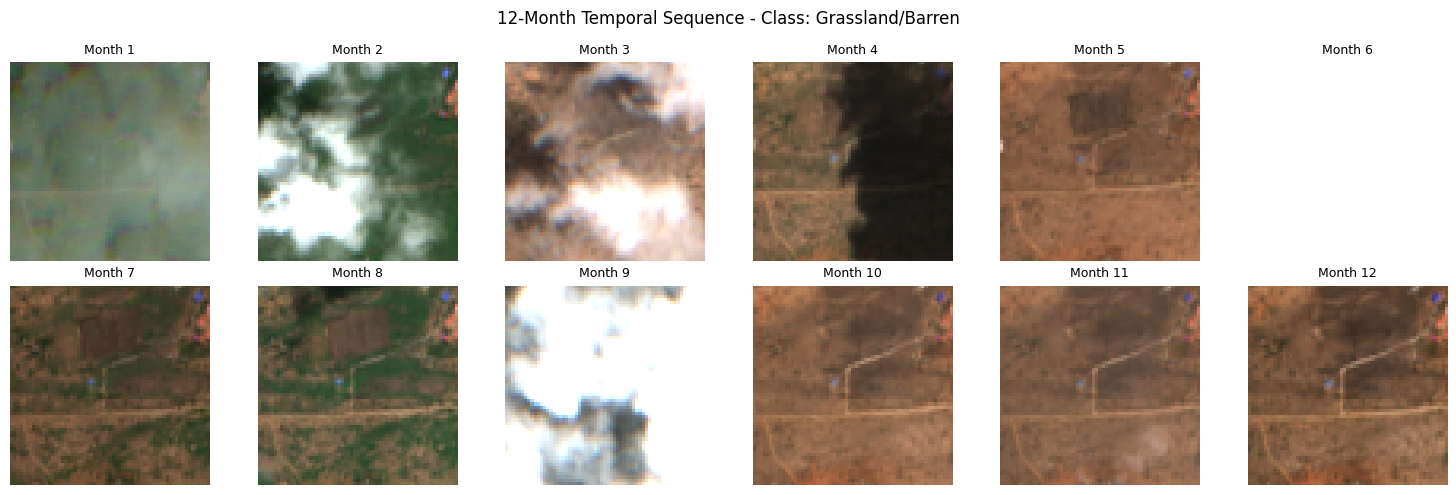

In [ ]:
# Display temporal sequence for one sample
sample_window = train_windows[0]

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes = axes.flatten()

for t in range(12):
    ax = axes[t]
    rgb = load_rgb_image(sample_window, DATASET_PATH, timestep=t)
    if rgb is not None:
        ax.imshow(rgb)
        ax.set_title(f"Month {t+1}", fontsize=9)
    else:
        ax.text(0.5, 0.5, "Missing", ha='center', va='center', fontsize=8)
    ax.axis('off')

label = get_label_from_window(sample_window, DATASET_PATH)
plt.suptitle(f"12-Month Temporal Sequence - Class: {CLASS_NAMES[label]}", fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Part A: Using OlmoEarth Embeddings (No Fine-tuning)

In this section, we'll:
1. Load the pre-trained OlmoEarth Nano model
2. Extract embeddings for all samples
3. Train simple classifiers on top

This approach is **fast** and requires **minimal GPU memory**, making it ideal for rapid prototyping.

### 4.1 Load OlmoEarth Model

OlmoEarth models are available in multiple sizes. We'll use **Nano** (1.4M parameters) for this tutorial, but the same approach works with larger models for better accuracy.

In [ ]:
# Load OlmoEarth Nano model with pre-trained weights from HuggingFace
print("Loading OlmoEarth Nano model...")
print("(Pre-trained weights from: allenai/OlmoEarth-v1-Nano)")

model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO)
model.eval()
encoder = model.encoder.to(device)

num_params = sum(p.numel() for p in encoder.parameters())
print(f"\nModel loaded!")
print(f"  Parameters: {num_params:,} ({num_params/1e6:.1f}M)")
print(f"  Embedding dimension: 128")
print(f"  Device: {device}")

Loading OlmoEarth Nano model...
(Pre-trained weights from: allenai/OlmoEarth-v1-Nano)


/Users/joer/.conda/lib/python3.12/importlib/__init__.py:90: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)



Model loaded!
  Parameters: 1,361,408 (1.4M)
  Embedding dimension: 128
  Device: mps


### 4.2 Define Data Loading and Embedding Extraction Functions

In [ ]:
# Load OlmoEarth normalization config (mean/std per band)
NORM_CONFIG = load_computed_config()['sentinel2_l2a']

# Band names in order they appear in the stacked data (10m, 20m, 60m resolution bands)
BAND_NAMES = ["B02", "B03", "B04", "B08", "B05", "B06", "B07", "B8A", "B11", "B12", "B01", "B09"]

def normalize_sentinel2(data, std_multiplier=2):
    """Apply OlmoEarth normalization to Sentinel-2 data."""
    data = data.astype(np.float32).copy()
    T, C, H, W = data.shape
    for t in range(T):
        for c, band_name in enumerate(BAND_NAMES):
            if band_name in NORM_CONFIG:
                mean = NORM_CONFIG[band_name]['mean']
                std = NORM_CONFIG[band_name]['std']
                min_val = mean - std_multiplier * std
                max_val = mean + std_multiplier * std
                data[t, c] = (data[t, c] - min_val) / (max_val - min_val)
    return np.clip(data, 0, 1)

def load_window_data(window, dataset_path, max_timesteps=12, normalize=True):
    """Load Sentinel-2 data and label from a window.

    Returns:
        s2_data: numpy array of shape (T, 12, H, W) with all Sentinel-2 bands (normalized if normalize=True)
        label: integer class label
    """
    window_root = window.get_window_root(dataset_path, window.group, window.name)
    layers_dir = window_root / "layers"

    all_timesteps = []

    for t in range(max_timesteps):
        layer_name = "sentinel2" if t == 0 else f"sentinel2.{t}"
        layer_dir = layers_dir / layer_name

        if not layer_dir.exists():
            continue

        # Load and resample all bandsets to same resolution
        bandset_data = []
        target_size = None

        for bandset_name, n_bands in BANDSET_INFO:
            path = layer_dir / bandset_name / "geotiff.tif"
            if path.exists():
                with rasterio.open(str(path)) as src:
                    data = src.read()  # (C, H, W)
                    if target_size is None:
                        target_size = data.shape[1:]
                    # Resample to target size if needed
                    if data.shape[1:] != target_size:
                        factors = (1, target_size[0]/data.shape[1], target_size[1]/data.shape[2])
                        data = zoom(data, factors, order=1)
                    bandset_data.append(data)

        if len(bandset_data) == 3:
            combined = np.concatenate(bandset_data, axis=0)  # (12, H, W)
            all_timesteps.append(combined)

    if not all_timesteps:
        return None, None

    s2_data = np.stack(all_timesteps, axis=0)  # (T, 12, H, W)

    # Apply OlmoEarth normalization
    if normalize:
        s2_data = normalize_sentinel2(s2_data)

    # Load label - find valid label (not nodata)
    label_path = layers_dir / "label" / "category" / "geotiff.tif"
    if label_path.exists():
        with rasterio.open(str(label_path)) as src:
            label = src.read(1)
            unique = np.unique(label)
            valid_labels = unique[(unique != NODATA_VALUE) & (unique < NUM_CLASSES)]
            if len(valid_labels) > 0:
                center_label = int(valid_labels[0])
            else:
                center_label = None
    else:
        center_label = None

    return s2_data, center_label

In [ ]:
def extract_embedding(encoder, s2_data, device, patch_size=4):
    """Extract embedding from Sentinel-2 data using OlmoEarth.

    Args:
        encoder: OlmoEarth encoder model
        s2_data: numpy array of shape (T, 12, H, W)
        device: torch device
        patch_size: patch size for the encoder

    Returns:
        embedding: numpy array of shape (128,)
    """
    T, C, H, W = s2_data.shape

    # Convert to tensor
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)

    # Rearrange to OlmoEarth format: (B, H, W, T, C)
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    # Create mask for 3 bandsets
    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value,
                      dtype=torch.int32, device=device)

    # Timestamps (months 0-11)
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)  # month

    sample = MaskedOlmoEarthSample(
        sentinel2_l2a=s2_tensor,
        sentinel2_l2a_mask=mask,
        timestamps=timestamps
    )

    with torch.no_grad():
        output = encoder(sample, fast_pass=True, patch_size=patch_size)
        tokens = output['tokens_and_masks'].sentinel2_l2a
        embedding = tokens.mean(dim=[1, 2, 3, 4])  # Pool to (B, C)

    return embedding.float().cpu().numpy()[0]

### 4.3 Extract Embeddings

In [ ]:
# Extract embeddings for all samples
# This takes ~2-3 minutes on a T4 GPU

print("Extracting embeddings for training set...")
train_embeddings = []
train_labels = []

for window in tqdm(train_windows, desc="Train"):
    s2_data, label = load_window_data(window, DATASET_PATH)
    if s2_data is None or label is None or label >= NUM_CLASSES:
        continue
    try:
        emb = extract_embedding(encoder, s2_data, device)
        train_embeddings.append(emb)
        train_labels.append(label)
    except Exception as e:
        continue

train_embeddings = np.array(train_embeddings)
train_labels = np.array(train_labels)
print(f"Train: {len(train_embeddings)} samples, shape {train_embeddings.shape}")

print("\nExtracting embeddings for validation set...")
val_embeddings = []
val_labels = []

for window in tqdm(val_windows, desc="Val"):
    s2_data, label = load_window_data(window, DATASET_PATH)
    if s2_data is None or label is None or label >= NUM_CLASSES:
        continue
    try:
        emb = extract_embedding(encoder, s2_data, device)
        val_embeddings.append(emb)
        val_labels.append(label)
    except Exception as e:
        continue

val_embeddings = np.array(val_embeddings)
val_labels = np.array(val_labels)
print(f"Val: {len(val_embeddings)} samples, shape {val_embeddings.shape}")

Extracting embeddings for training set...


Train:   0%|          | 0/1115 [00:00<?, ?it/s]

/Users/joer/.conda/lib/python3.12/site-packages/torch/nn/functional.py:4704: UserWarning: The operator 'aten::_upsample_bicubic2d_aa.out' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:14.)
  return torch._C._nn._upsample_bicubic2d_aa(


Train: 1115 samples, shape (1115, 128)

Extracting embeddings for validation set...


Val:   0%|          | 0/344 [00:00<?, ?it/s]

Val: 344 samples, shape (344, 128)


### 4.4 Train Simple Classifiers on Embeddings

In [ ]:
# Normalize embeddings using StandardScaler (for Linear Probe and segmentation)
import warnings
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_emb_scaled = scaler.fit_transform(train_embeddings)
val_emb_scaled = scaler.transform(val_embeddings)

# Replace any NaN/inf from zero-variance features after scaling
train_emb_scaled = np.nan_to_num(train_emb_scaled, nan=0.0, posinf=0.0, neginf=0.0)
val_emb_scaled = np.nan_to_num(val_emb_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Also create L2-normalized versions for kNN (cosine similarity)
train_emb_norm = preprocessing.normalize(train_embeddings, norm='l2')
val_emb_norm = preprocessing.normalize(val_embeddings, norm='l2')

# Train kNN classifier
print("Training kNN classifier (k=20, cosine similarity)...")
k = min(20, len(train_embeddings))
knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')
knn.fit(train_emb_norm, train_labels)

knn_preds = knn.predict(val_emb_norm)
knn_accuracy = accuracy_score(val_labels, knn_preds)
print(f"kNN Accuracy: {knn_accuracy:.1%}")

# Train linear probe on scaled embeddings
print("\nTraining linear probe (logistic regression)...")
lp = LogisticRegression(max_iter=1000, solver='lbfgs')
lp.fit(train_emb_scaled, train_labels)

lp_preds = lp.predict(val_emb_scaled)
lp_accuracy = accuracy_score(val_labels, lp_preds)
print(f"Linear Probe Accuracy: {lp_accuracy:.1%}")

Training kNN classifier (k=20, cosine similarity)...
kNN Accuracy: 71.5%

Training linear probe (logistic regression)...
Linear Probe Accuracy: 68.3%


/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:206: RuntimeWarning: invalid value encountered in mat

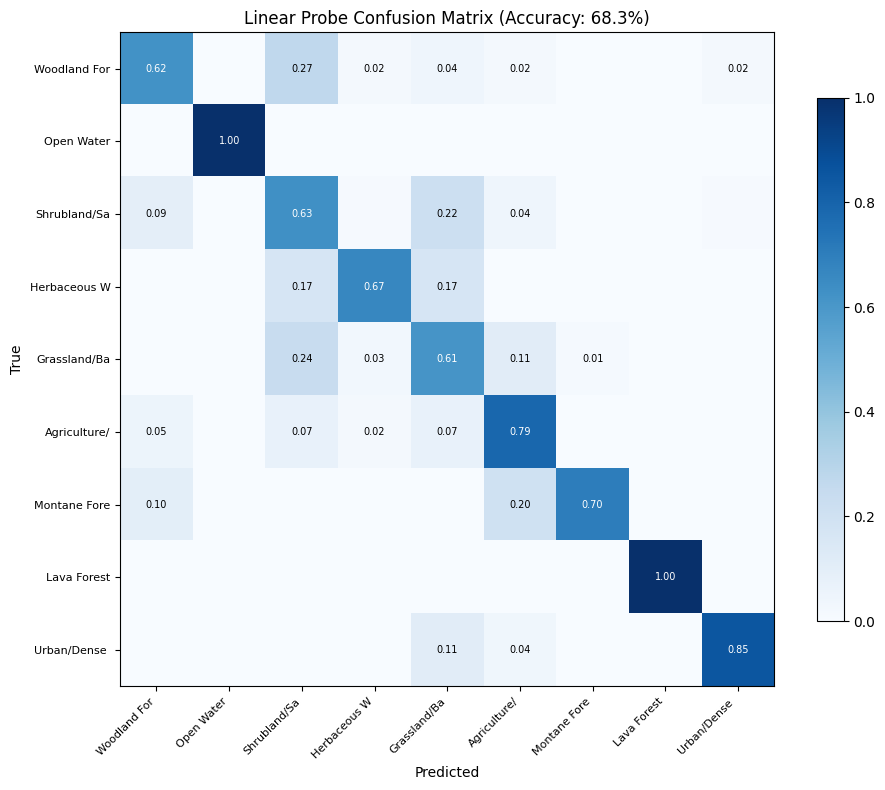

In [ ]:
# Show confusion matrix for linear probe
cm = confusion_matrix(val_labels, lp_preds)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels([c[:12] for c in CLASS_NAMES], rotation=45, ha='right', fontsize=8)
ax.set_yticklabels([c[:12] for c in CLASS_NAMES], fontsize=8)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Linear Probe Confusion Matrix (Accuracy: {lp_accuracy:.1%})")

# Add text annotations
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_norm[i, j] > 0.01:  # Only show if > 1%
            color = 'white' if cm_norm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                   color=color, fontsize=7)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Show results summary
print("\n" + "="*50)
print("EMBEDDING-BASED RESULTS (No Fine-tuning)")
print("="*50)
print(f"Training samples: {len(train_embeddings)}")
print(f"Validation samples: {len(val_embeddings)}")
print(f"Embedding dimension: {train_embeddings.shape[1]}")
print(f"\nkNN Accuracy (k={k}):     {knn_accuracy:.1%}")
print(f"Linear Probe Accuracy: {lp_accuracy:.1%}")


EMBEDDING-BASED RESULTS (No Fine-tuning)
Training samples: 1115
Validation samples: 344
Embedding dimension: 128

kNN Accuracy (k=20):     71.5%
Linear Probe Accuracy: 68.3%


### 4.5 Visualize Segmentation Predictions

Let's see how our embedding-based classifier performs on full images, generating per-patch segmentation maps.

Generating segmentation predictions for 4 windows...


/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b

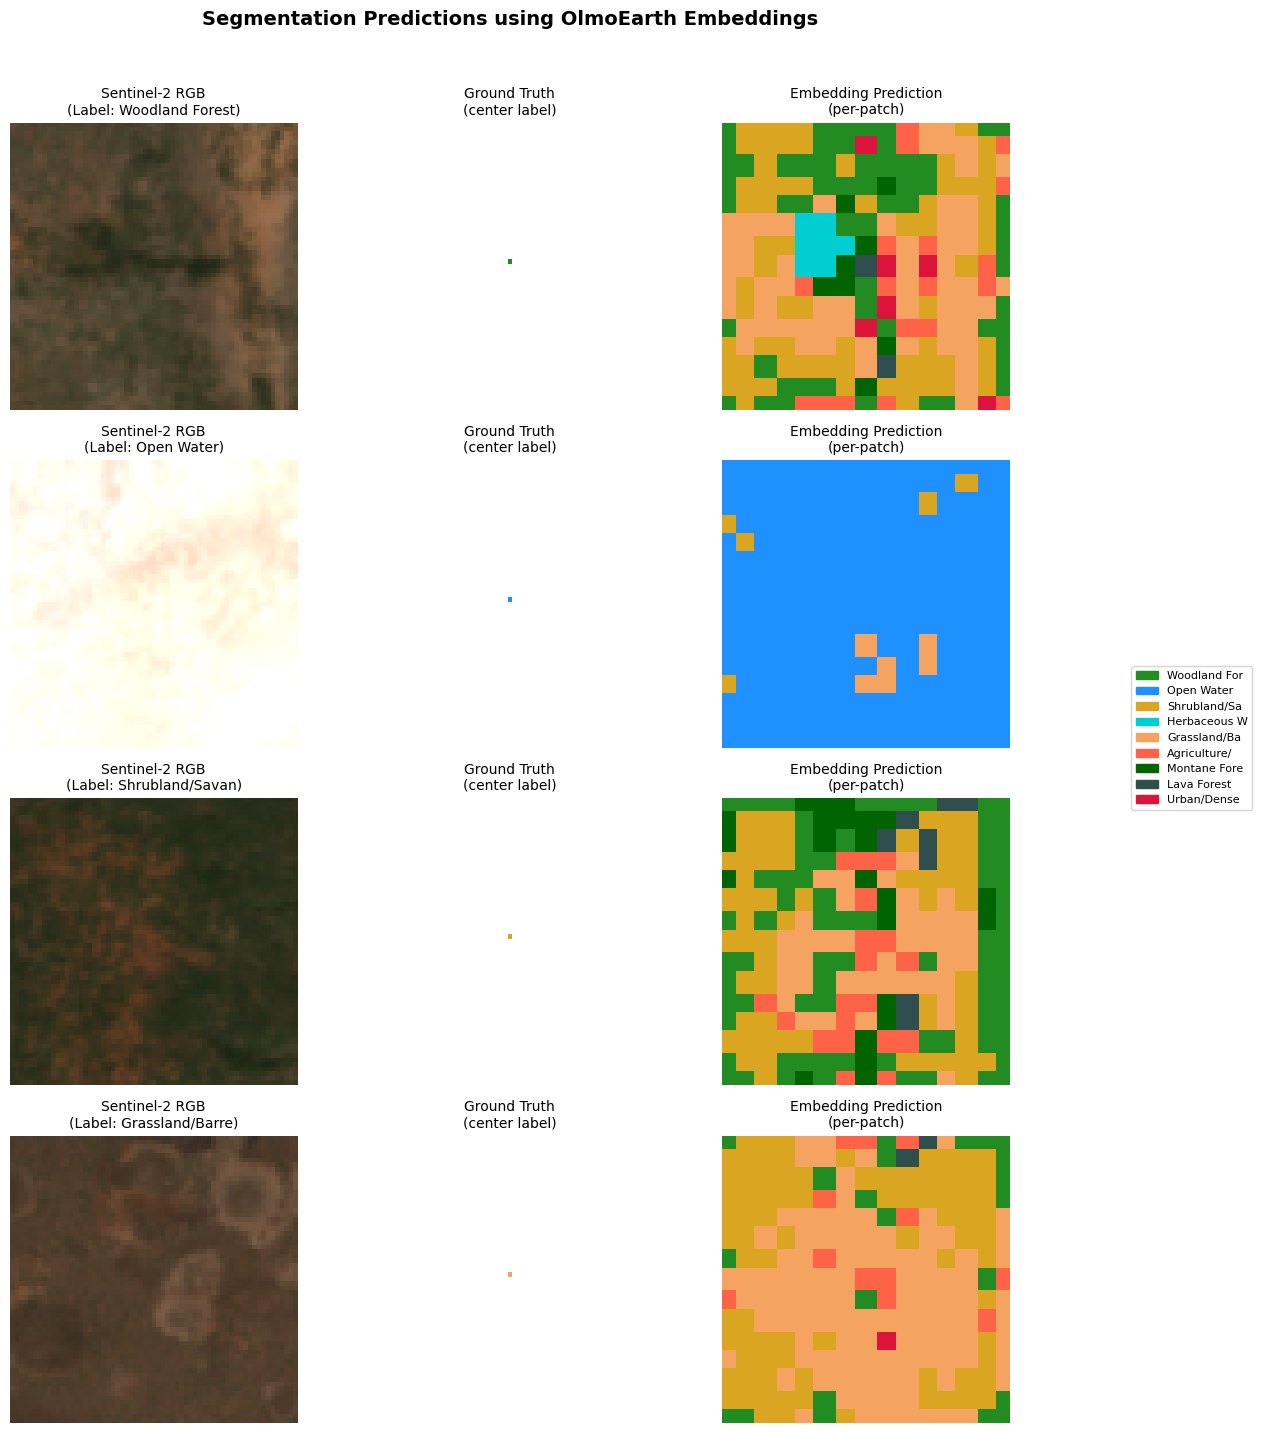

In [ ]:
# Visualize segmentation predictions on validation samples
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# Use CLASS_COLORS defined earlier
cmap = ListedColormap(CLASS_COLORS)

# Select validation windows from different classes
demo_classes = [0, 1, 2, 4]  # Woodland, Water, Shrubland, Grassland
demo_windows = []
for cls_id in demo_classes:
    cls_windows = [w for w in val_windows if get_label_from_window(w, DATASET_PATH) == cls_id]
    if cls_windows:
        demo_windows.append((cls_windows[0], cls_id))

print(f"Generating segmentation predictions for {len(demo_windows)} windows...")

def predict_segmentation(encoder, s2_data, classifier, scaler, output_shape, device):
    """Generate per-patch segmentation prediction using embeddings."""
    T, C, H, W = s2_data.shape
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value, dtype=torch.int32, device=device)
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)

    sample = MaskedOlmoEarthSample(sentinel2_l2a=s2_tensor, sentinel2_l2a_mask=mask, timestamps=timestamps)

    with torch.no_grad():
        output = encoder(sample, fast_pass=True, patch_size=4)
        tokens = output['tokens_and_masks'].sentinel2_l2a.mean(dim=(3, 4))  # (B, H_p, W_p, C)

    patch_embs = tokens.float().cpu().numpy()[0]
    H_p, W_p, C_emb = patch_embs.shape

    # Predict for each patch
    embs_flat = patch_embs.reshape(-1, C_emb)
    embs_scaled = scaler.transform(embs_flat)
    preds = classifier.predict(embs_scaled).reshape(H_p, W_p)

    # Upsample to output size
    from scipy.ndimage import zoom
    scale_h = output_shape[0] / H_p
    scale_w = output_shape[1] / W_p
    return zoom(preds.astype(float), (scale_h, scale_w), order=0).astype(int)

# Create visualization - 3 columns: RGB, Ground Truth (center label), Embedding Prediction
fig, axes = plt.subplots(len(demo_windows), 3, figsize=(11, 3.5 * len(demo_windows)))
if len(demo_windows) == 1:
    axes = axes.reshape(1, -1)

for i, (window, true_label) in enumerate(demo_windows):
    # Use last timestep (often dry season, less cloudy) for clearer visualization
    rgb = load_rgb_image(window, DATASET_PATH, timestep=11)
    if rgb is None:  # Fallback to any available timestep
        rgb = load_rgb_image(window, DATASET_PATH, timestep=0)
    s2_data, _ = load_window_data(window, DATASET_PATH)

    # Load ground truth label map
    window_root = window.get_window_root(DATASET_PATH, window.group, window.name)
    label_path = window_root / "layers" / "label" / "category" / "geotiff.tif"
    with rasterio.open(str(label_path)) as src:
        label_map = src.read(1)

    # Get prediction
    pred_map = predict_segmentation(encoder, s2_data, lp, scaler, label_map.shape, device)

    # Column 1: RGB
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"Sentinel-2 RGB\n(Label: {CLASS_NAMES[true_label][:15]})", fontsize=10)
    axes[i, 0].axis('off')

    # Column 2: Ground truth (with center marker)
    masked_labels = np.ma.masked_where(label_map >= len(CLASS_NAMES), label_map)
    axes[i, 1].imshow(masked_labels, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    h, w = label_map.shape
    circle = plt.Circle((w//2, h//2), 3, color='white', fill=False, linewidth=2)
    axes[i, 1].add_patch(circle)
    axes[i, 1].set_title("Ground Truth\n(center label)", fontsize=10)
    axes[i, 1].axis('off')

    # Column 3: Embedding prediction
    axes[i, 2].imshow(pred_map, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 2].set_title("Embedding Prediction\n(per-patch)", fontsize=10)
    axes[i, 2].axis('off')

# Add legend
patches = [mpatches.Patch(color=CLASS_COLORS[i], label=CLASS_NAMES[i][:12]) for i in range(len(CLASS_NAMES))]
fig.legend(handles=patches, loc='center right', bbox_to_anchor=(1.18, 0.5), fontsize=8)
plt.suptitle("Segmentation Predictions using OlmoEarth Embeddings", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Part B: Fine-tuning OlmoEarth

Now let's fine-tune the full model for better accuracy using rslearn's training pipeline.

Fine-tuning involves:
1. Adding a segmentation head on top of the encoder
2. Training end-to-end with cross-entropy loss
3. Using learning rate scheduling and encoder freezing for stability

In [ ]:
# Clear GPU memory from embedding extraction
# (safe to re-run even if these variables were already deleted)
for _var in ['encoder', 'model']:
    if _var in dir():
        del globals()[_var]
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("GPU memory cleared for fine-tuning")

GPU memory cleared for fine-tuning


In [ ]:
# Configure fine-tuning parameters
# Training is split into two phases:
#   1. FREEZE_EPOCHS: Train decoder only (encoder frozen)
#   2. UNFREEZE_EPOCHS: Train entire model (encoder unfrozen)

# Default: 2+2 = 4 epochs (~15-20 min on T4)
# For better accuracy, increase to 5+25 = 30 epochs (~2-3 hours on T4)
FREEZE_EPOCHS = 10    # Epochs with frozen encoder (trains decoder only)
UNFREEZE_EPOCHS = 30  # Epochs with unfrozen encoder (trains full model)
NUM_EPOCHS = FREEZE_EPOCHS + UNFREEZE_EPOCHS

print(f"Training configuration:")
print(f"  Freeze epochs:   {FREEZE_EPOCHS} (decoder only)")
print(f"  Unfreeze epochs: {UNFREEZE_EPOCHS} (full model)")
print(f"  Total epochs:    {NUM_EPOCHS}")

# Create fine-tuning configuration
finetune_config = f'''
model:
  class_path: rslearn.train.lightning_module.RslearnLightningModule
  init_args:
    model:
      class_path: rslearn.models.multitask.MultiTaskModel
      init_args:
        encoder:
          - class_path: rslearn.models.olmoearth_pretrain.model.OlmoEarth
            init_args:
              model_id: OLMOEARTH_V1_NANO
              patch_size: 4
        decoders:
          segment:
            - class_path: rslearn.models.upsample.Upsample
              init_args:
                scale_factor: 4
            - class_path: rslearn.models.conv.Conv
              init_args:
                in_channels: 128
                out_channels: 10
                kernel_size: 1
                activation:
                  class_path: torch.nn.Identity
            - class_path: rslearn.train.tasks.segmentation.SegmentationHead
    lr: 0.0001
    plateau: true
    plateau_factor: 0.2
    plateau_patience: 2
data:
  class_path: rslearn.train.data_module.RslearnDataModule
  init_args:
    path: data/dataset
    inputs:
      sentinel2_l2a:
        data_type: raster
        layers: [sentinel2]
        bands: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
        passthrough: true
        dtype: FLOAT32
        load_all_item_groups: true
        load_all_layers: true
      label:
        data_type: raster
        layers: [label]
        bands: [category]
        is_target: true
        dtype: INT32
    task:
      class_path: rslearn.train.tasks.multi_task.MultiTask
      init_args:
        tasks:
          segment:
            class_path: rslearn.train.tasks.segmentation.SegmentationTask
            init_args:
              num_classes: 10
              zero_is_invalid: false
              nodata_value: 9
        input_mapping:
          segment:
            label: targets
    batch_size: 4
    num_workers: 4
    default_config:
      transforms:
        - class_path: rslearn.train.transforms.pad.Pad
          init_args:
            size: 31
            mode: center
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.crop.Crop
          init_args:
            crop_size: 16
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.models.olmoearth_pretrain.norm.OlmoEarthNormalize
          init_args:
            band_names:
              sentinel2_l2a: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
    train_config:
      transforms:
        - class_path: rslearn.train.transforms.pad.Pad
          init_args:
            size: 31
            mode: center
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.crop.Crop
          init_args:
            crop_size: 16
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.train.transforms.flip.Flip
          init_args:
            image_selectors: [sentinel2_l2a, target/segment/classes, target/segment/valid]
        - class_path: rslearn.models.olmoearth_pretrain.norm.OlmoEarthNormalize
          init_args:
            band_names:
              sentinel2_l2a: [B02, B03, B04, B08, B05, B06, B07, B8A, B11, B12, B01, B09]
      groups: [spatial_split]
      tags:
        split: train
    val_config:
      groups: [spatial_split]
      tags:
        split: val
trainer:
  max_epochs: {NUM_EPOCHS}
  accelerator: gpu
  devices: 1
  log_every_n_steps: 10
  enable_progress_bar: true
  callbacks:
    - class_path: lightning.pytorch.callbacks.ModelCheckpoint
      init_args:
        dirpath: checkpoints
        save_top_k: 1
        save_last: true
        monitor: val_segment/accuracy
        mode: max
    - class_path: lightning.pytorch.callbacks.TQDMProgressBar
      init_args:
        refresh_rate: 10
    - class_path: rslearn.train.callbacks.freeze_unfreeze.FreezeUnfreeze
      init_args:
        module_selector: [model, encoder, 0]
        unfreeze_at_epoch: {FREEZE_EPOCHS}
        unfreeze_lr_factor: 10
'''

with open('finetune_config.yaml', 'w') as f:
    f.write(finetune_config)
print("Fine-tuning config saved to finetune_config.yaml")

Training configuration:
  Freeze epochs:   10 (decoder only)
  Unfreeze epochs: 30 (full model)
  Total epochs:    40
Fine-tuning config saved to finetune_config.yaml


In [ ]:
# Run fine-tuning
# Default (2+2 epochs): ~15-20 min on T4 GPU
# Full training (5+25 epochs): ~2-3 hours on T4 GPU (best results)
import subprocess
import sys

print("="*60)
print("STARTING FINE-TUNING")
print("="*60)
print(f"Total epochs: {NUM_EPOCHS}")
print(f"  Phase 1: {FREEZE_EPOCHS} epochs (encoder frozen)")
print(f"  Phase 2: {UNFREEZE_EPOCHS} epochs (encoder unfrozen)")
print("-"*60)
print("You should see progress bars for each epoch below...")
print("-"*60 + "\n")

# Run training with real-time output
process = subprocess.Popen(
    ["rslearn", "model", "fit", "--config", "finetune_config.yaml"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env={**os.environ, "WANDB_MODE": "disabled", "PYTHONUNBUFFERED": "1", "MPLBACKEND": "agg"}
)

training_output_lines = []
for line in process.stdout:
    print(line, end='')  # Show output in real-time
    training_output_lines.append(line)

process.wait()
training_output = ''.join(training_output_lines)

print("\n" + "="*60)
if process.returncode == 0:
    print("FINE-TUNING COMPLETED SUCCESSFULLY!")
else:
    print(f"FINE-TUNING FAILED (exit code: {process.returncode})")
print("="*60)

STARTING FINE-TUNING
Total epochs: 40
  Phase 1: 10 epochs (encoder frozen)
  Phase 2: 30 epochs (encoder unfrozen)
------------------------------------------------------------
You should see progress bars for each epoch below...
------------------------------------------------------------

format=2026-02-05 11:58:33,454 loglevel=INFO   logger=rslearn.main main() L853  Using multiprocessing context: <multiprocessing.context.ForkServerContext object at 0x105939910>
/Users/joer/iclr_tutorial_track/.venv/lib/python3.12/site-packages/lightning/pytorch/cli.py:553: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['model', 'fit', '--config', 'finetune_config.yaml'], args=['fit', '--config', 'finetune_config.yaml'].
/Users/joer/iclr_tutorial_track/.venv/lib/python3.12/site-packages/rslearn/models/olmoearth_pretrain/model.py:11: 

In [ ]:
# Evaluate the fine-tuned model
import re

# Find best checkpoint
best_ckpt = "checkpoints/last.ckpt"
if os.path.exists("checkpoints"):
    ckpts = [f for f in os.listdir("checkpoints") if f.endswith(".ckpt") and f != "last.ckpt"]
    if ckpts:
        best_ckpt = f"checkpoints/{ckpts[0]}"

print(f"Evaluating checkpoint: {best_ckpt}")

# Run validation on the checkpoint
validate_process = subprocess.Popen(
    ["rslearn", "model", "validate", "--config", "finetune_config.yaml", "--ckpt_path", best_ckpt],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    env={**os.environ, "WANDB_MODE": "disabled", "MPLBACKEND": "agg"}
)

validate_output_lines = []
for line in validate_process.stdout:
    print(line, end='')
    validate_output_lines.append(line)
validate_process.wait()
validate_output = ''.join(validate_output_lines)

# Parse validation accuracy
finetune_accuracy = None
for pattern in [r'val_segment/accuracy\s+([0-9.]+)', r'val_segment/accuracy[:\s│\|]+([0-9.]+)']:
    match = re.search(pattern, validate_output)
    if match:
        finetune_accuracy = float(match.group(1))
        break

print("\n" + "="*50)
print("FINE-TUNING RESULTS")
print("="*50)
print(f"Checkpoint: {best_ckpt}")
if finetune_accuracy is not None:
    print(f"Validation Accuracy: {finetune_accuracy:.1%}")
else:
    print("Could not parse accuracy. Check output above for 'val_segment/accuracy'.")
print("="*50)

Evaluating checkpoint: checkpoints/epoch=32-step=9207.ckpt
format=2026-02-05 12:32:58,107 loglevel=INFO   logger=rslearn.main main() L853  Using multiprocessing context: <multiprocessing.context.ForkServerContext object at 0x100bbdac0>
/Users/joer/iclr_tutorial_track/.venv/lib/python3.12/site-packages/lightning/pytorch/cli.py:553: LightningCLI's args parameter is intended to run from within Python like if it were from the command line. To prevent mistakes it is not recommended to provide both args and command line arguments, got: sys.argv[1:]=['model', 'validate', '--config', 'finetune_config.yaml', '--ckpt_path', 'checkpoints/epoch=32-step=9207.ckpt'], args=['validate', '--config', 'finetune_config.yaml', '--ckpt_path', 'checkpoints/epoch=32-step=9207.ckpt'].
/Users/joer/iclr_tutorial_track/.venv/lib/python3.12/site-packages/rslearn/models/olmoearth_pretrain/model.py:11: UserWarning: olmo-core not installed. Running in inference-only mode. For training: pip install olmoearth-pretrain[

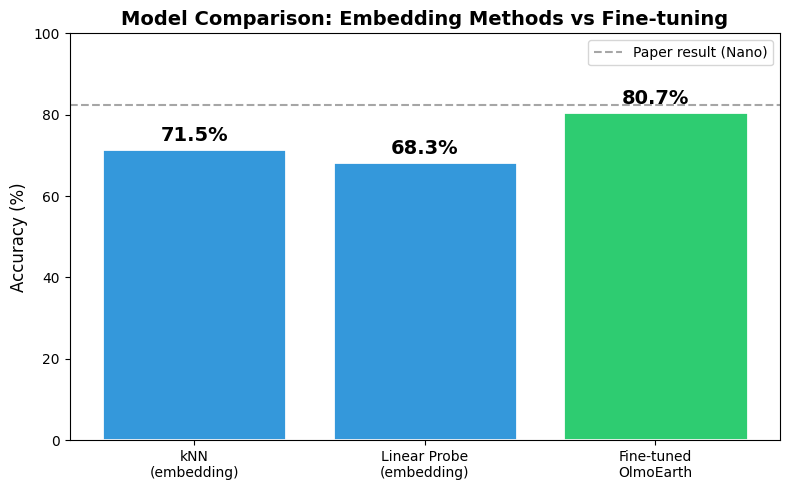


Fine-tuning improved accuracy by 9.1% over best embedding method!


In [ ]:
# Visualize accuracy comparison
methods = ['kNN\n(embedding)', 'Linear Probe\n(embedding)', 'Fine-tuned\nOlmoEarth']
accuracies = [knn_accuracy, lp_accuracy, finetune_accuracy if finetune_accuracy else 0]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#3498db', '#2ecc71']
bars = ax.bar(methods, [a * 100 for a in accuracies], color=colors, edgecolor='white', linewidth=2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Comparison: Embedding Methods vs Fine-tuning', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.axhline(y=82.5, color='gray', linestyle='--', alpha=0.7, label='Paper result (Nano)')
ax.legend()

plt.tight_layout()
plt.show()

if finetune_accuracy:
    improvement = finetune_accuracy - max(knn_accuracy, lp_accuracy)
    print(f"\nFine-tuning improved accuracy by {improvement:.1%} over best embedding method!")

### Compare Segmentation: Embeddings vs Fine-tuned

Now let's compare the segmentation predictions from our embedding-based classifier vs the fine-tuned model.

Loading pretrained encoder for embedding comparison...
  Loaded pretrained encoder
Loading fine-tuned model from: checkpoints/epoch=32-step=9207.ckpt
  Loaded 103 encoder weights + decoder head


/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/joer/.conda/lib/python3.12/site-packages/sklearn/utils/extmath.py:227: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b

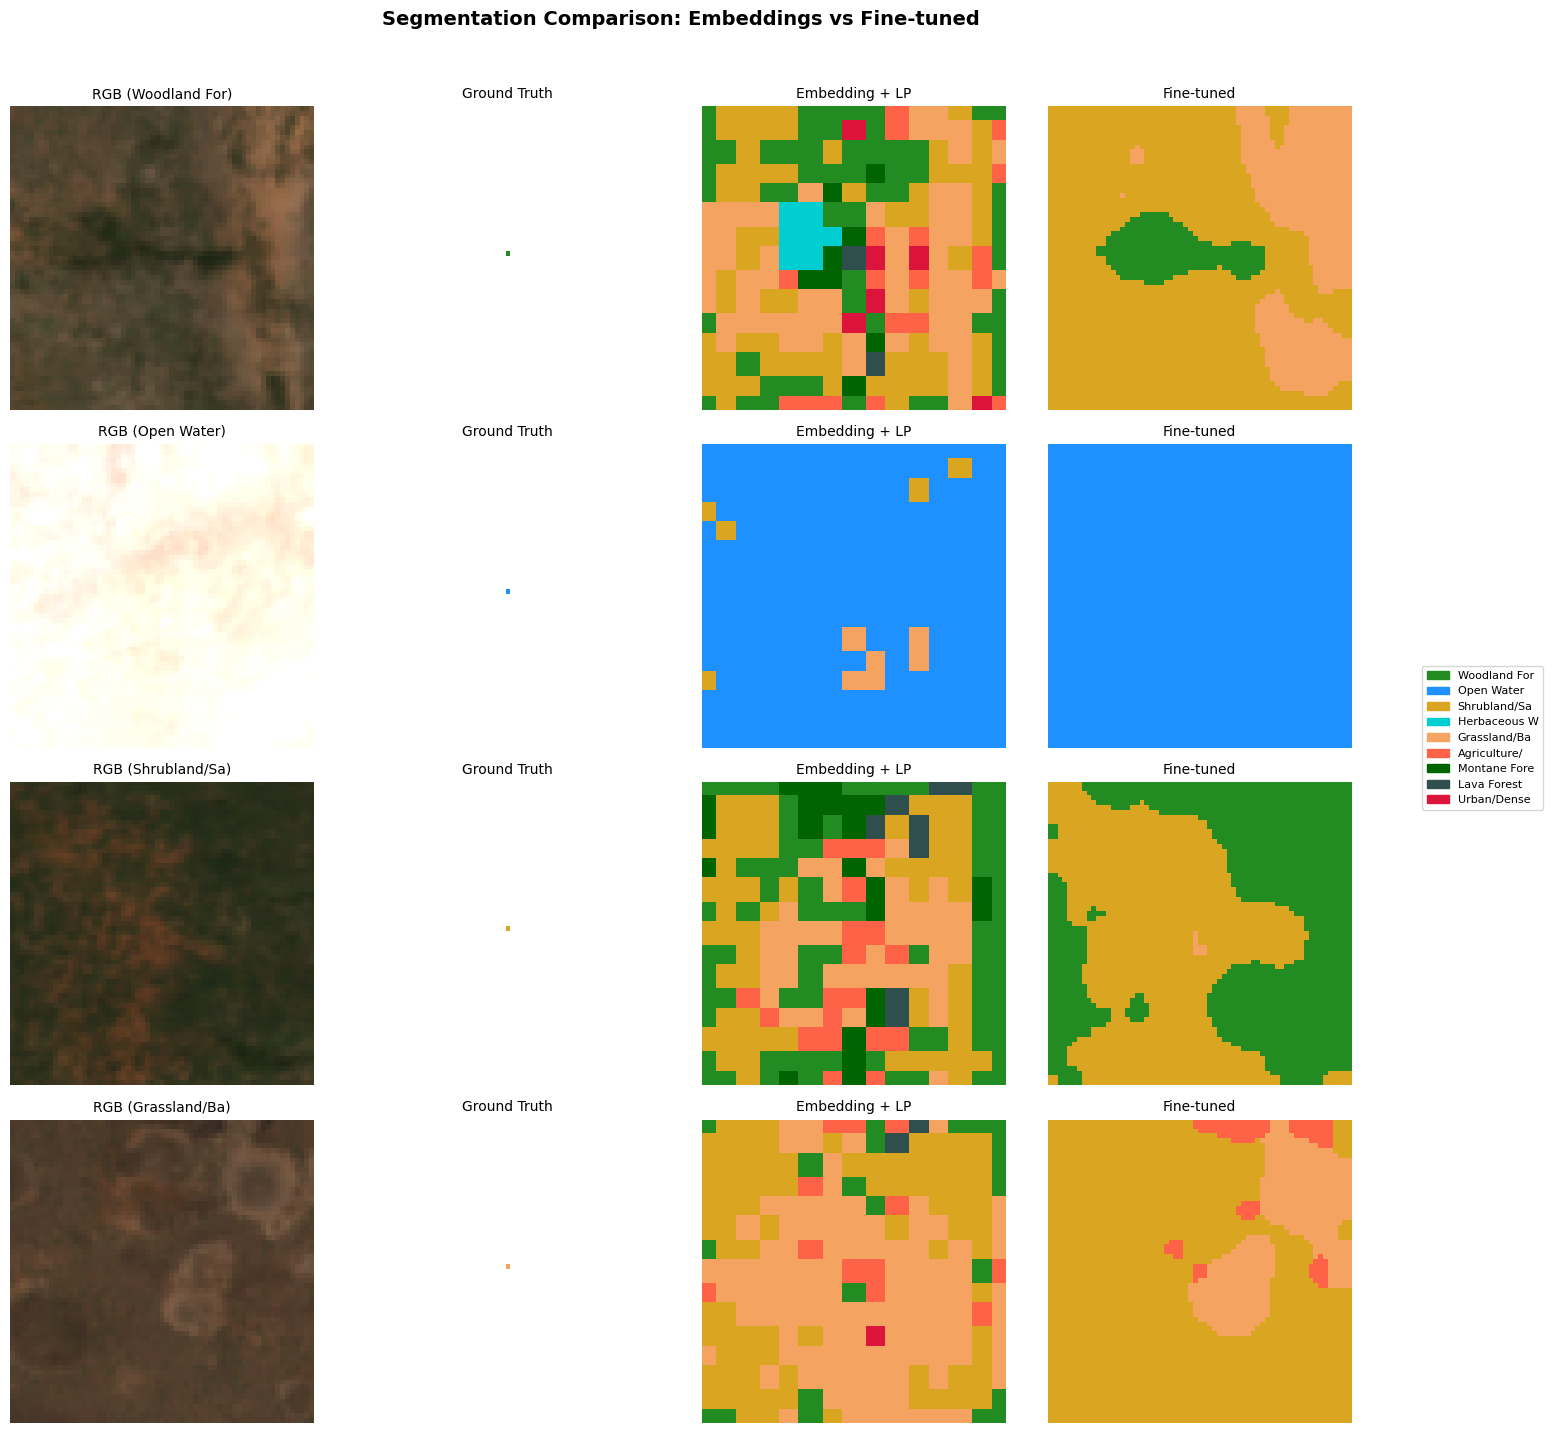

In [ ]:
# Load pretrained encoder for embedding comparison (was deleted earlier to save memory)
print("Loading pretrained encoder for embedding comparison...")
encoder = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).encoder.to(device)
encoder.eval()
print("  Loaded pretrained encoder")

# Load fine-tuned model weights from checkpoint
# Find best checkpoint
best_ckpt = "checkpoints/last.ckpt"
if os.path.exists("checkpoints"):
    ckpts = [f for f in os.listdir("checkpoints") if f.endswith(".ckpt") and f != "last.ckpt"]
    if ckpts:
        best_ckpt = f"checkpoints/{ckpts[0]}"

print(f"Loading fine-tuned model from: {best_ckpt}")
checkpoint = torch.load(best_ckpt, map_location=device, weights_only=False)
state_dict = checkpoint['state_dict']

# Load fine-tuned encoder weights
ft_encoder = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).encoder.to(device)
encoder_state = {k.replace('model.encoder.0.model.', ''): v
                 for k, v in state_dict.items() if 'encoder.0.model.' in k}
ft_encoder.load_state_dict(encoder_state, strict=False)
ft_encoder.eval()

# Load decoder head weights
ft_head = torch.nn.Sequential(
    torch.nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False),
    torch.nn.Conv2d(128, 10, kernel_size=1)
).to(device)
for k, v in state_dict.items():
    if 'decoders.segment.1.layer.weight' in k:
        ft_head[1].weight.data = v
    if 'decoders.segment.1.layer.bias' in k:
        ft_head[1].bias.data = v

print(f"  Loaded {len(encoder_state)} encoder weights + decoder head")

def predict_finetuned(s2_data, output_shape):
    """Run fine-tuned model on normalized S2 data."""
    T, C, H, W = s2_data.shape
    s2_tensor = torch.from_numpy(s2_data.astype(np.float32)).to(device)
    s2_tensor = rearrange(s2_tensor, 't c h w -> 1 h w t c')

    mask = torch.full((1, H, W, T, 3), MaskValue.ONLINE_ENCODER.value, dtype=torch.int32, device=device)
    timestamps = torch.zeros((1, T, 3), dtype=torch.int32, device=device)
    timestamps[0, :, 1] = torch.arange(T, device=device)
    sample = MaskedOlmoEarthSample(sentinel2_l2a=s2_tensor, sentinel2_l2a_mask=mask, timestamps=timestamps)

    with torch.no_grad():
        output = ft_encoder(sample, fast_pass=True, patch_size=4)
        tokens = output['tokens_and_masks'].sentinel2_l2a.mean(dim=(3, 4))
        features = rearrange(tokens, 'b h w c -> b c h w')
        logits = ft_head(features)
        pred = logits.argmax(dim=1).cpu().numpy()[0]

    # Upsample to output size
    scale_h, scale_w = output_shape[0] / pred.shape[0], output_shape[1] / pred.shape[1]
    return zoom(pred.astype(float), (scale_h, scale_w), order=0).astype(int)

# Compare predictions side by side
fig, axes = plt.subplots(len(demo_windows), 4, figsize=(14, 3.5 * len(demo_windows)))
if len(demo_windows) == 1:
    axes = axes.reshape(1, -1)

for i, (window, true_label) in enumerate(demo_windows):
    # Use last timestep (often dry season, less cloudy) for clearer visualization
    rgb = load_rgb_image(window, DATASET_PATH, timestep=11)
    if rgb is None:  # Fallback to any available timestep
        rgb = load_rgb_image(window, DATASET_PATH, timestep=0)
    s2_data, _ = load_window_data(window, DATASET_PATH)
    window_root = window.get_window_root(DATASET_PATH, window.group, window.name)
    with rasterio.open(str(window_root / "layers" / "label" / "category" / "geotiff.tif")) as src:
        label_map = src.read(1)

    # Embedding prediction
    emb_pred = predict_segmentation(encoder, s2_data, lp, scaler, label_map.shape, device)

    # Fine-tuned prediction
    ft_pred = predict_finetuned(s2_data, label_map.shape)

    # Plot
    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"RGB ({CLASS_NAMES[true_label][:12]})", fontsize=10)
    axes[i, 0].axis('off')

    masked = np.ma.masked_where(label_map >= len(CLASS_NAMES), label_map)
    axes[i, 1].imshow(masked, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 1].set_title("Ground Truth", fontsize=10)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(emb_pred, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 2].set_title("Embedding + LP", fontsize=10)
    axes[i, 2].axis('off')

    axes[i, 3].imshow(ft_pred, cmap=cmap, vmin=0, vmax=len(CLASS_NAMES)-1)
    axes[i, 3].set_title("Fine-tuned", fontsize=10)
    axes[i, 3].axis('off')

fig.legend(handles=patches, loc='center right', bbox_to_anchor=(1.12, 0.5), fontsize=8)
plt.suptitle("Segmentation Comparison: Embeddings vs Fine-tuned", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 6. Results Summary

In [ ]:
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"\nEmbedding-based (no fine-tuning):")
print(f"  kNN Accuracy:          {knn_accuracy:.1%}")
print(f"  Linear Probe Accuracy: {lp_accuracy:.1%}")
print(f"\nFine-tuned OlmoEarth Nano ({NUM_EPOCHS} epochs):")
if finetune_accuracy is not None:
    print(f"  Validation Accuracy:   {finetune_accuracy:.1%}")
else:
    print(f"  Validation Accuracy:   (see training logs above)")
print(f"\nReference (from OlmoEarth paper, 30 epochs of fine-tuning):")
print(f"  OlmoEarth Nano (S2):   82.5%  (increase epochs above for similar results)")
print(f"  OlmoEarth Base (S2):   87.0%  (change model_id to OLMOEARTH_V1_BASE)")
print("="*60)

# Show improvement from fine-tuning
if finetune_accuracy is not None:
    best_embedding = max(knn_accuracy, lp_accuracy)
    improvement = finetune_accuracy - best_embedding
    print(f"\nFine-tuning improvement: +{improvement:.1%} over best embedding method")

FINAL RESULTS SUMMARY

Embedding-based (no fine-tuning):
  kNN Accuracy:          71.5%
  Linear Probe Accuracy: 68.3%

Fine-tuned OlmoEarth Nano (40 epochs):
  Validation Accuracy:   80.7%

Reference (from OlmoEarth paper, 30 epochs of fine-tuning):
  OlmoEarth Nano (S2):   82.5%  (increase epochs above for similar results)
  OlmoEarth Base (S2):   87.0%  (change model_id to OLMOEARTH_V1_BASE)

Fine-tuning improvement: +9.1% over best embedding method


### When to Use Which Approach?

| Scenario | Recommended Approach |
|----------|---------------------|
| Rapid prototyping, exploring data | Embeddings + kNN/LP |
| Limited GPU resources | Embeddings + kNN/LP |
| Small labeled dataset (<100 samples) | Embeddings + kNN/LP |
| Maximum accuracy needed | Fine-tuning |
| Production deployment | Fine-tuning |
| Task very different from pre-training | Fine-tuning |

**Pro tip**: Start with embeddings to quickly validate your approach, then fine-tune for production!

---
## 7. Next Steps & Resources

### Scaling Up

| Model | Parameters | Embedding Dim | Expected Accuracy |
|-------|------------|---------------|-------------------|
| **Nano** (this tutorial) | 1.4M | 128 | ~82% |
| Tiny | 6.2M | 192 | ~85% |
| Base | 90M | 768 | ~87% |
| Large | 300M | 1024 | ~85%* |

To use a larger model, change `model_id: OLMOEARTH_V1_NANO` to `OLMOEARTH_V1_BASE` and update `in_channels` accordingly.

### Resources

- **OlmoEarth Models**: [huggingface.co/allenai](https://huggingface.co/collections/allenai/olmoearth)
- **rslearn Library**: [github.com/allenai/rslearn](https://github.com/allenai/rslearn)
- **OlmoEarth Projects**: [github.com/allenai/olmoearth_projects](https://github.com/allenai/olmoearth_projects)

### Citation

If you use OlmoEarth in your work, please cite:

```bibtex
@misc{herzog2025olmoearth,
  title={OlmoEarth: Stable Latent Image Modeling for Multimodal Earth Observation},
  author={Henry Herzog and Favyen Bastani and Yawen Zhang and Gabriel Tseng and Joseph Redmon and others},
  year={2025},
  eprint={2511.13655},
  archivePrefix={arXiv}
}
```

---

**Congratulations!** You've learned how to:
1. Load and explore remote sensing datasets with rslearn
2. Extract embeddings from OlmoEarth for rapid prototyping
3. Train simple classifiers (kNN, linear probe) on embeddings
4. Fine-tune OlmoEarth for maximum accuracy

Happy mapping! 🌍